# Calculating Bus Stop Access to Enschede Schools

In [1]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

import contextily as cx
import osmnx
import pandas as pd
import numpy as np

## Creating the Enschede GeoDataFrame
### Inspecting the Dutch Municipalities GeoPackage

In [2]:
data_folder = '../../data'
fiona.listlayers(f'{data_folder}/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [3]:
cities = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='cities')
cities.shape

(342, 6)

In [4]:
cities.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
0,GM0263,Maasdriel,0263,25,Gelderland,"MULTIPOLYGON (((146637.319 416737.822, 146600 ..."


In [5]:
cities.loc[cities['naam']=='Enschede']

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
82,GM0153,Enschede,0153,23,Overijssel,"MULTIPOLYGON (((252038.609 465222.168, 252036...."


### Creating the Enschede Subset

In [6]:
enschede = cities[cities['naam']=='Enschede']
enschede.shape

(1, 6)

In [7]:
enschede.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
82,GM0153,Enschede,0153,23,Overijssel,"MULTIPOLYGON (((252038.609 465222.168, 252036...."


### Visualising the Subset

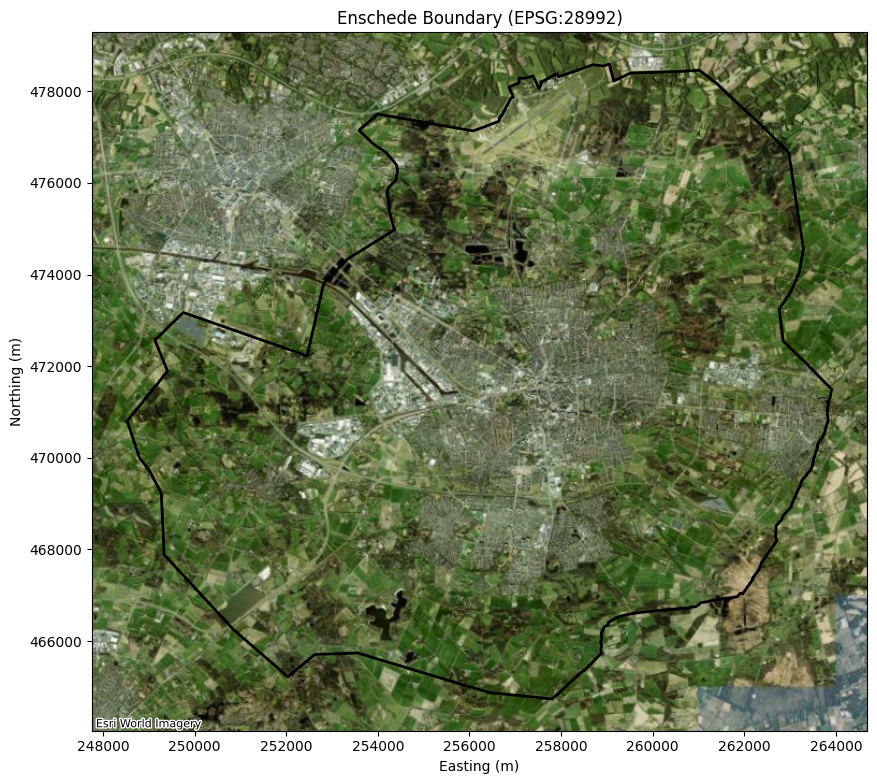

In [8]:
fig, ax = plt.subplots(figsize=(10,10))
enschede.plot(ax=ax, color='none', linewidth=2)

basemap = cx.providers.Esri.WorldImagery
basemap['attribution'] = 'Esri World Imagery'
cx.add_basemap(ax, source=basemap, crs=enschede.crs)

ax.set_title(f'Enschede Boundary ({enschede.crs})')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

## Retrieving School and Bus Stop Features for Enschede From OpenStreetMap
### Downloading School Points

In [9]:
schools = osmnx.features_from_place('Enschede, Netherlands', tags={'amenity':'school'})
schools.shape

(103, 41)

In [10]:
schools = schools.reset_index()
print(schools.columns.to_list())

['element', 'id', 'geometry', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'email', 'isced:level', 'name', 'operator', 'operator:website', 'operator:wikidata', 'phone', 'religion', 'school', 'source', 'source:date', 'website', 'wikidata', 'created_by', 'wheelchair', 'addr:country', 'facebook', 'entrance', 'capacity', 'isced', 'max_age', 'min_age', 'pedagogy', 'denomination', 'check_date', 'internet_access', 'opening_hours', 'toilets:wheelchair', 'building', 'building:levels', 'ref:bag', 'roof:levels', 'start_date', 'landuse', 'type']


In [11]:
schools = schools[['id', 'name', 'geometry']]
schools = schools[schools.geometry.geom_type=='Point']

schools.shape

(78, 3)

In [12]:
print(schools.crs)

epsg:4326


In [13]:
schools = schools.to_crs('EPSG:28992')
schools.tail(1)

,id,name,geometry
77,10543682045,SBO De Huifkar,POINT (256812.121 472482.118)


### Downloading Bus Stop Points

In [14]:
bus_stops = osmnx.features_from_place('Enschede, Netherlands', tags={'highway': 'bus_stop'})
bus_stops.shape

(358, 19)

In [15]:
print(bus_stops.columns.to_list())

['geometry', 'bench', 'bin', 'bus', 'highway', 'lit', 'name', 'public_transport', 'ref:IFOPT', 'shelter', 'tactile_paving', 'zone', 'check_date:shelter', 'wheelchair', 'ref', 'fixme', 'official_name', 'passenger_information_display', 'operator']


In [16]:
bus_stops = bus_stops[['name', 'geometry']]
bus_stops = bus_stops[bus_stops.geometry.geom_type=='Point']

bus_stops.shape

(358, 2)

In [17]:
print(bus_stops.crs)

epsg:4326


In [18]:
bus_stops = bus_stops.to_crs('EPSG:28992')
bus_stops.head(1)

,,name,geometry
element,id,,
node,249202448,Station Kennispark,POINT (254287.149 473261.02)


## Spatial Join: Buffer Analysis
### Creating Walkshed Buffers (400m radius)
Source: https://morphocode.com/the-5-minute-walk/

In [19]:
schools['buffer'] = schools['geometry'].buffer(400)
schools[1:5]

,id,name,geometry,buffer
1,30889003,Prinseschool,POINT (259000.608 470344.779),"POLYGON ((259400.608 470344.779, 259398.682 47..."
2,92655310,Montessori Basisschool Het Zeggelt,POINT (257929.258 472866.967),"POLYGON ((258329.258 472866.967, 258327.332 47..."
3,248415961,Greijdanus,POINT (258167.961 473299.657),"POLYGON ((258567.961 473299.657, 258566.034 47..."
4,615389520,OBS Het Wooldrik,POINT (259936.295 470936.322),"POLYGON ((260336.295 470936.322, 260334.369 47..."


<Axes: >

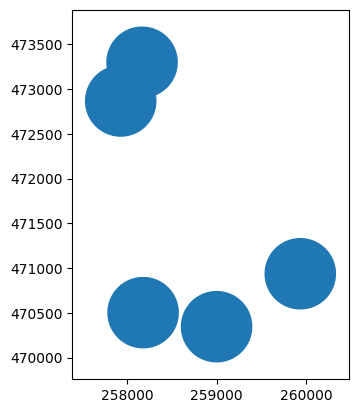

In [20]:
schools['buffer'].head().plot()

### Intersecting School Buffers with Bus Stops

In [21]:
schools = schools.set_geometry('buffer')

joined_gdf = gpd.sjoin(schools, bus_stops, how='left', predicate='intersects')
joined_gdf.shape

(353, 7)

In [22]:
joined_gdf.tail(1)

,id_left,name_left,geometry,buffer,element,id_right,name_right
77,10543682045,SBO De Huifkar,POINT (256812.121 472482.118),"POLYGON ((257212.121 472482.118, 257210.195 47...",node,677662628.0,Goolkatenweg


In [23]:
grouped_gdf = joined_gdf.groupby('id_left')
len(grouped_gdf)

78

### Calculating Total Intersected Bus Stops for Each School

In [24]:
bus_stop_count = grouped_gdf['id_right'].count().reset_index()
bus_stop_count.head(1)

,id_left,id_right
0,30238784,5


In [25]:
grouped_df = bus_stop_count.groupby(by='id_right')
len(grouped_df)

12

In [26]:
bus_stop_frequency = pd.DataFrame(grouped_df['id_right'].count())
bus_stop_frequency.head(1)

,id_right
id_right,
0,8


### DataFrame Cleaning

In [27]:
bus_stop_frequency = bus_stop_frequency.rename(columns={'id_right': 'frequency'})

bus_stop_frequency = bus_stop_frequency.reset_index()
bus_stop_frequency = bus_stop_frequency.rename(columns={'id_right': 'value'})
bus_stop_frequency['value'] = bus_stop_frequency['value'].astype(str)

bus_stop_frequency.head(1)

,value,frequency
0,0,8


## Calculating Descriptive Statistics
### Creating the Statistical DataFrame

In [28]:
bus_stop_stats = pd.DataFrame(bus_stop_count['id_right'].describe()).reset_index()
bus_stop_stats.head(1)

,index,id_right
0,count,78.0


### DataFrame Cleaning

In [29]:
bus_stop_stats['id_right'] = np.round(bus_stop_stats['id_right'], 1)
bus_stop_stats = bus_stop_stats.rename(columns={'index': 'key', 'id_right': 'value'})

bus_stop_stats.head(1)

,key,value
0,count,78.0


## Plotting the Final Results

### Bar Chart

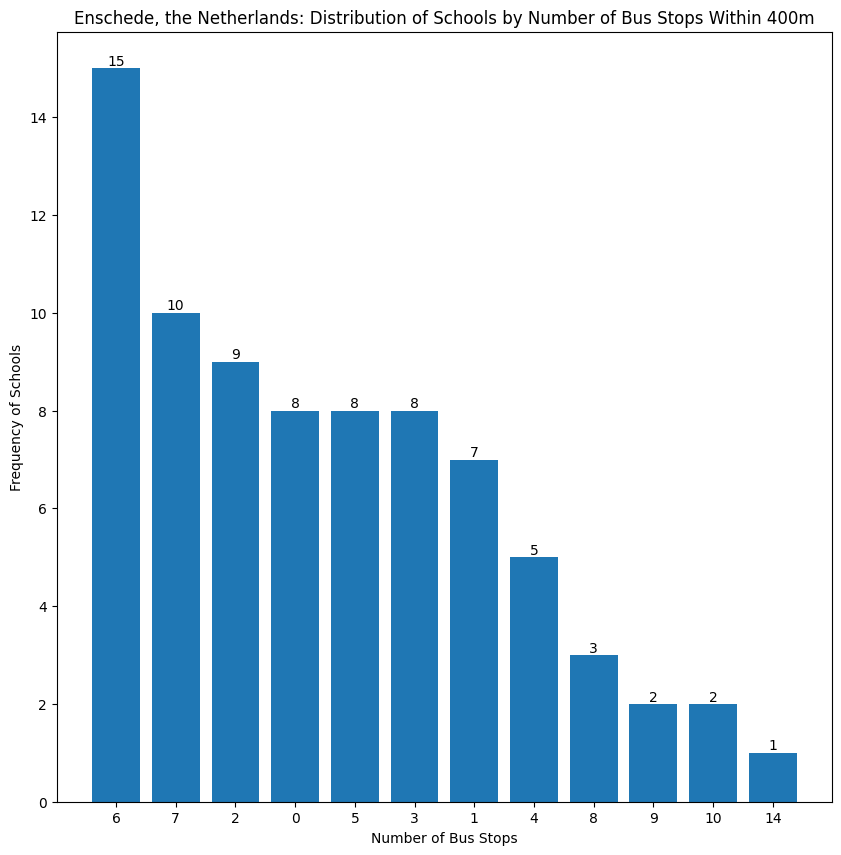

In [30]:
sorted_bus_stop_frequency = bus_stop_frequency.sort_values(by='frequency', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10,10))
bars = ax.bar(sorted_bus_stop_frequency['value'], sorted_bus_stop_frequency['frequency'])

ax.bar_label(bars, sorted_bus_stop_frequency['frequency'])

ax.set_title('Enschede, the Netherlands: Distribution of Schools by Number of Bus Stops Within 400m')
ax.set_xlabel('Number of Bus Stops')
ax.set_ylabel('Frequency of Schools')

plt.show()

### Histogram

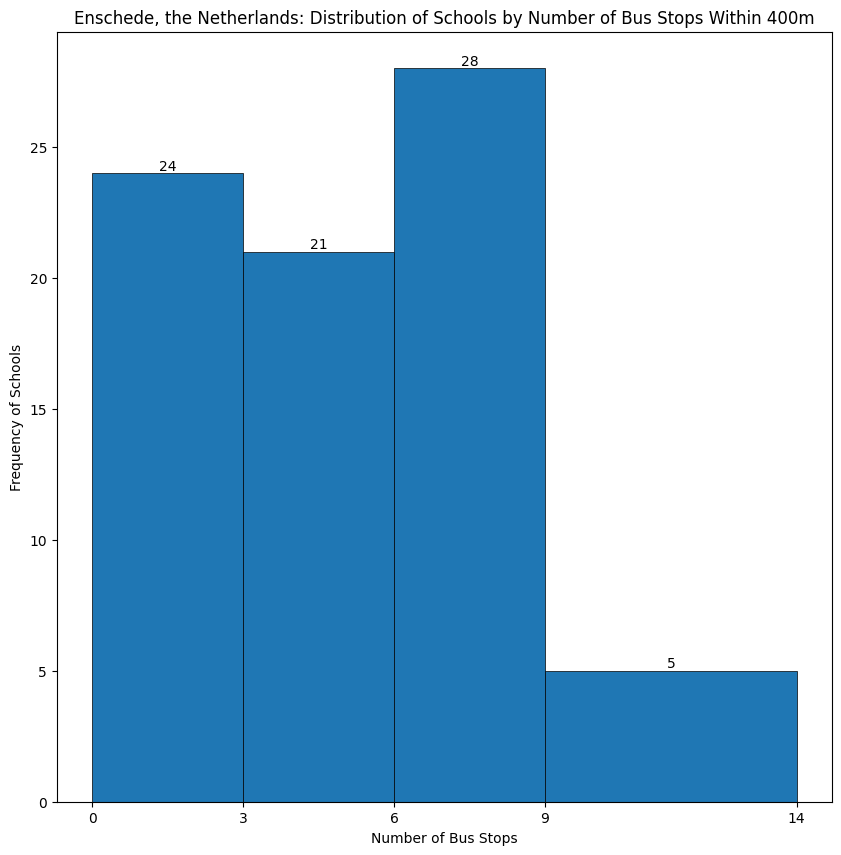

In [31]:
fig, ax = plt.subplots(figsize=(10,10))
bins = [i 
        for i in bus_stop_frequency['value'].astype(int) 
        if i%3 == 0] + [max(bus_stop_frequency['value'].astype(int))]

counts, edges, patches = ax.hist(
    bus_stop_frequency['value'], 
    weights=bus_stop_frequency['frequency'],
    bins=bins,
    edgecolor='black',
    linewidth=0.5
)
ax.bar_label(patches, counts.astype(int))

ax.set_xticks(bins)
ax.set_xticklabels(bins)

ax.set_title('Enschede, the Netherlands: Distribution of Schools by Number of Bus Stops Within 400m')
ax.set_xlabel('Number of Bus Stops')
ax.set_ylabel('Frequency of Schools')

plt.show()

### Descriptive Statistics

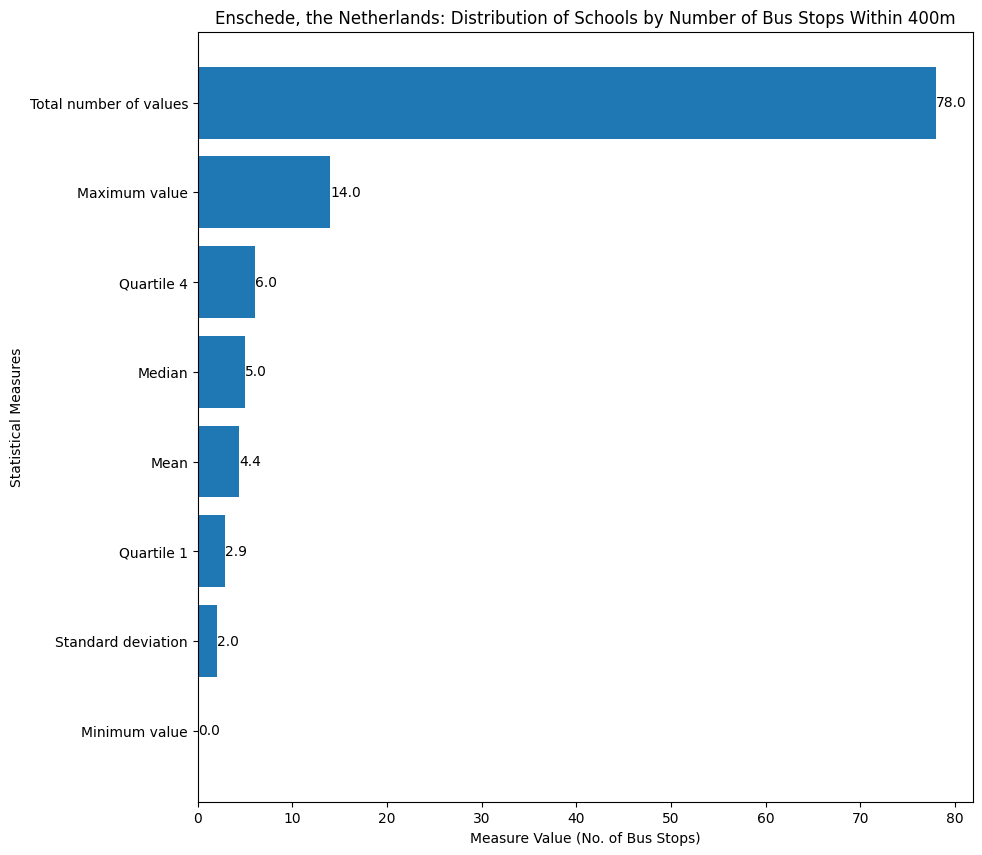

In [32]:
sorted_stats = bus_stop_stats.sort_values(by='value', ascending=True)

fig, ax = plt.subplots(figsize=(10,10))
bars = ax.barh(sorted_stats['key'], sorted_stats['value'])

yticklabels = [
    'Total number of values',
    'Maximum value',
    'Quartile 4',
    'Median',
    'Mean',
    'Quartile 1',
    'Standard deviation',
    'Minimum value'
]
yticklabels.reverse()

ax.bar_label(bars, sorted_stats['value'])
ax.set_yticks(sorted_stats['key'])
ax.set_yticklabels(yticklabels)


ax.set_title('Enschede, the Netherlands: Distribution of Schools by Number of Bus Stops Within 400m')
ax.set_xlabel('Measure Value (No. of Bus Stops)')
ax.set_ylabel('Statistical Measures')

plt.show()